# Hafta 5 · Ders 9 — Bölütleme, Hough Dönüşümü ve k-Ortalamalar

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

Şimdiye kadar *noktalar* (köşeler, damlalar) bulduk. Şimdi pikselleri *bölgelere* gruplayıp küresel
*şekiller* tespit ediyoruz. Üç klasik araç, hepsi sıfırdan inşa edilmiş:

- Bir görüntüyü renge göre tutarlı bölgelere bölütlemek için **k-ortalamalar (k-means)** kümeleme.
- Kırık veya gürültülü olsalar bile küresel doğruları tespit etmek için **Hough dönüşümü**.
- Modern bölütlemeyi hazırlayan **bölge-tabanlı** düşünceye kısa bir bakış.

Bunlar görüntü-işleme geçmişinizle doğrudan bağlantılıdır — k-ortalamalar bölütlemesi, Riemann
eğri-evrimi çalışmanızdaki varyasyonel/PDE bölütlemesinin ayrık kuzenidir.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.cv_utils import show, show_row, sample_rgb, sample_gray, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. k-ortalamalar renk bölütlemesi

Her pikseli 3B renk uzayında $(R, G, B)$ bir nokta olarak ele al. **k-ortalamalar**, bu noktaları
yakınsamaya kadar iki adımı dönüşümlü uygulayarak $k$ kümeye böler:

1. Her pikseli en yakın küme merkezine **ata**.
2. Her merkezi, atanan piksellerinin ortalamasına **güncelle**.

Her pikseli küme merkeziyle yeniden renklendirmek görüntüyü $k$ düz renk bölgesine bölütler. Bu,
sıfırdan uygulanan Lloyd algoritmasıdır.

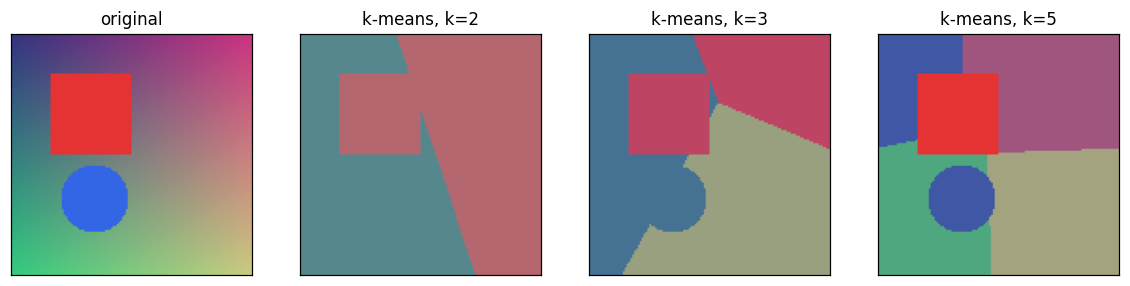

In [2]:
def kmeans(X, k, iters=20, seed=0):
    rng = np.random.default_rng(seed)
    centers = X[rng.choice(len(X), k, replace=False)]
    for _ in range(iters):
        # ata: en yakın merkez (karesel Öklid mesafesi)
        d = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        labels = d.argmin(axis=1)
        # güncelle: her kümenin ortalaması
        new = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else centers[j]
                        for j in range(k)])
        if np.allclose(new, centers):
            break
        centers = new
    return labels, centers

rgb = sample_rgb(128)
pixels = rgb.reshape(-1, 3)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
show(rgb, "orijinal", ax=axes[0])
for ax, k in zip(axes[1:], [2, 3, 5]):
    labels, centers = kmeans(pixels, k)
    seg = centers[labels].reshape(rgb.shape)
    show(seg, f"k-ortalamalar, k={k}", ax=ax)
plt.show()

### Yakınsamayı doğrulama

k-ortalamaların, her adımda küme-içi kareler toplamını (amaç fonksiyonunu) azaltması garantilidir.
Bu amacı çizmek, uygulamamızın monoton biçimde yakınsadığını doğrular — referans kütüphanesi olmadan
bile iyi bir doğruluk kontrolü.

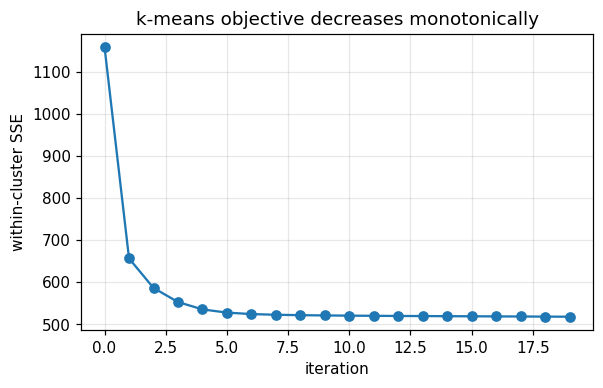

monotonically non-increasing: True


In [3]:
def kmeans_with_objective(X, k, iters=20, seed=0):
    rng = np.random.default_rng(seed)
    centers = X[rng.choice(len(X), k, replace=False)]
    history = []
    for _ in range(iters):
        d = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        labels = d.argmin(axis=1)
        history.append(d[np.arange(len(X)), labels].sum())   # küme-içi SSE
        centers = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else centers[j]
                            for j in range(k)])
    return history

hist = kmeans_with_objective(pixels, 4)
plt.figure(figsize=(6, 3.5))
plt.plot(hist, "o-", color="C0")
plt.xlabel("yineleme"); plt.ylabel("küme-içi SSE")
plt.title("k-ortalamalar amacı monoton biçimde azalır"); plt.grid(alpha=0.3); plt.show()
print("monoton biçimde artmayan:", all(hist[i] >= hist[i+1] - 1e-9 for i in range(len(hist)-1)))

## 2. Doğrular için Hough dönüşümü

Kenar tespiti dağınık kenar pikselleri verir; **Hough dönüşümü**, boşluklara ve gürültüye dayanıklı
biçimde onların oluşturduğu küresel *doğruları* bulur. Hile bir gösterim değişikliğidir. Bir doğru
şöyle yazılır:

$$ \\rho = x\\cos\\theta + y\\sin\\theta $$

Her kenar pikseli, içinden geçen *tüm* $(\\rho, \\theta)$ doğruları için oy verir ve **Hough
uzayında** bir sinüzoid çizer. Birçok sinüzoidin kesiştiği yerde, birçok piksel aynı doğru üzerinde
anlaşır — biriktiricide (accumulator) bir tepe. Oylamayı sıfırdan inşa ediyoruz.

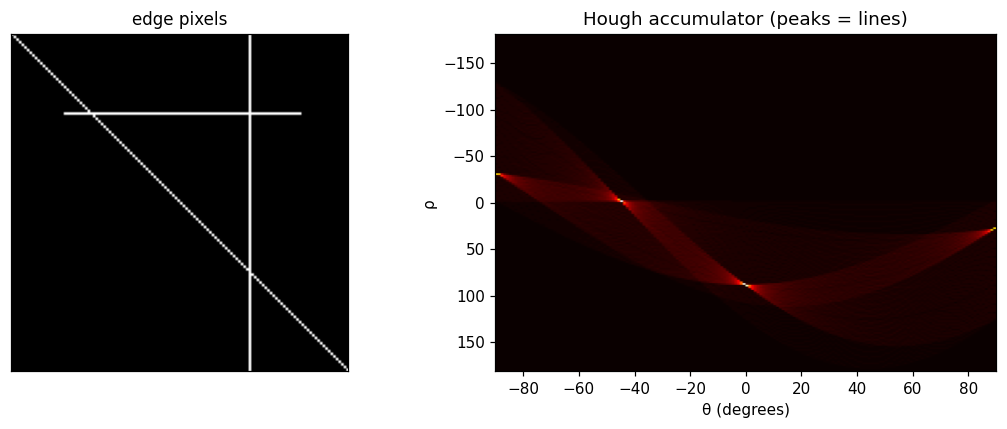

In [4]:
def hough_lines(edges, n_theta=180, n_rho=200):
    ys, xs = np.nonzero(edges)
    thetas = np.linspace(-np.pi/2, np.pi/2, n_theta)
    diag = np.hypot(*edges.shape)
    rhos = np.linspace(-diag, diag, n_rho)
    acc = np.zeros((n_rho, n_theta), dtype=int)
    cos, sin = np.cos(thetas), np.sin(thetas)
    for x, y in zip(xs, ys):
        r = x * cos + y * sin                       # her θ için ρ
        idx = np.clip(((r + diag) / (2*diag) * (n_rho-1)).astype(int), 0, n_rho-1)
        for t in range(n_theta):
            acc[idx[t], t] += 1
    return acc, rhos, thetas

# birkaç düz doğruya sahip sahne
img = np.zeros((128, 128))
for t in range(128):
    img[t, t] = 1                      # ana köşegen
    if 20 <= t < 110: img[30, t] = 1   # yatay parça
    img[t, 90] = 1                     # dikey doğru
acc, rhos, thetas = hough_lines(img > 0.5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
show(img, "kenar pikselleri", ax=axes[0])
axes[1].imshow(acc, cmap="hot", aspect="auto",
               extent=[np.degrees(thetas[0]), np.degrees(thetas[-1]), rhos[-1], rhos[0]])
axes[1].set_title("Hough biriktiricisi (tepeler = doğrular)")
axes[1].set_xlabel("θ (derece)"); axes[1].set_ylabel("ρ"); plt.tight_layout(); plt.show()

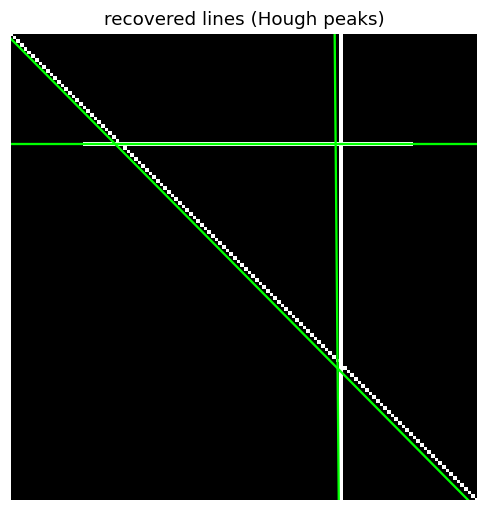

In [5]:
# en güçlü tepeleri bul ve geri kazanılan doğruları görüntüye geri çiz
def top_peaks(acc, rhos, thetas, n=3, min_dist=10):
    a = acc.copy(); peaks = []
    for _ in range(n):
        i, j = np.unravel_index(a.argmax(), a.shape)
        peaks.append((rhos[i], thetas[j]))
        a[max(0,i-min_dist):i+min_dist, max(0,j-min_dist):j+min_dist] = 0
    return peaks

peaks = top_peaks(acc, rhos, thetas, n=3)
fig, ax = plt.subplots(figsize=(5.5, 5.5)); ax.imshow(img, cmap="gray")
xx = np.array([0, 127])
for rho, theta in peaks:
    if abs(np.sin(theta)) > 1e-3:
        yy = (rho - xx * np.cos(theta)) / np.sin(theta)
        ax.plot(xx, yy, "-", color="lime", lw=1.5)
    else:
        ax.axvline(rho / np.cos(theta), color="lime", lw=1.5)
ax.set_xlim(0, 127); ax.set_ylim(127, 0); ax.set_title("geri kazanılan doğrular (Hough tepeleri)"); ax.axis("off")
plt.show()

## 3. Region growing: connectivity-based segmentation

A complementary idea to clustering: start from a seed pixel and **grow** a region by absorbing
neighbors whose intensity is close enough. This respects spatial connectivity (unlike pure color
k-means) and previews the region-merging logic inside classical and modern segmentation.

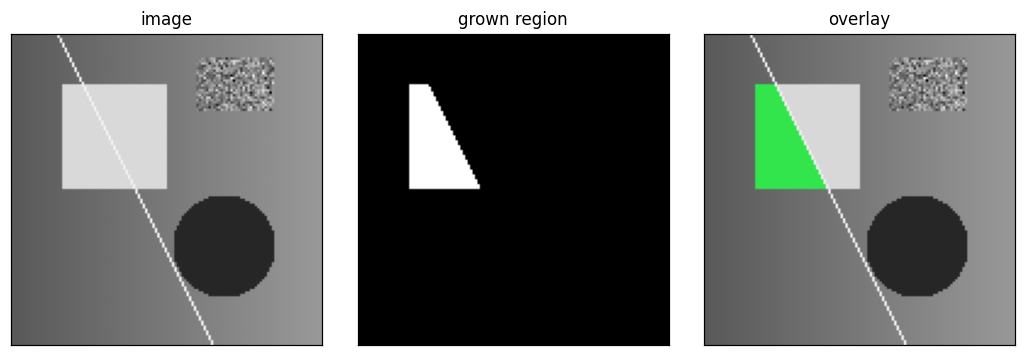

In [6]:
def region_grow(image, seed, tol=0.1):
    H, W = image.shape
    seen = np.zeros((H, W), bool)
    region = np.zeros((H, W), bool)
    val = image[seed]
    stack = [seed]
    while stack:
        y, x = stack.pop()
        if seen[y, x]:
            continue
        seen[y, x] = True
        if abs(image[y, x] - val) <= tol:
            region[y, x] = True
            for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
                ny, nx = y+dy, x+dx
                if 0 <= ny < H and 0 <= nx < W and not seen[ny, nx]:
                    stack.append((ny, nx))
    return region

gray = sample_gray(128)
region = region_grow(gray, seed=(30, 30), tol=0.08)   # parlak karenin içinde büyüt
overlay = np.stack([gray]*3, axis=-1)
overlay[region] = [0.2, 0.9, 0.3]
show_row([gray, region.astype(float), overlay],
         ["görüntü", "büyütülen bölge", "bindirme (overlay)"])
plt.show()

## 4. Where this shows up in modern vision

- **Semantic & instance segmentation.** Networks like U-Net and Mask R-CNN assign every pixel a class —
  the learned generalization of these region groupings. The classic objective (group similar, respect
  boundaries) is unchanged; the similarity is now learned.
- **Superpixels** (SLIC) are k-means in a joint color+position space, used to pre-group pixels before a
  network — directly this notebook's k-means with two extra coordinates.
- **The Hough idea** generalizes to voting-based detection (e.g. Hough forests, and the voting in some
  3D-detection and pose pipelines).
- **Color quantization.** k-means on pixel colors is exactly how images are reduced to a small palette
  (GIF compression).

Preview: SLIC-style superpixels via k-means in color+position space.

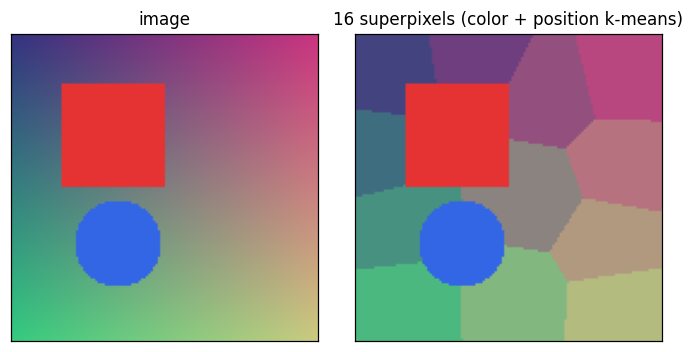

In [7]:
# süperpikseller: kümeler hem renk-tutarlı HEM DE kompakt olsun diye (R, G, B, x, y) üzerinde kümele
H, W, _ = rgb.shape
yy, xx = np.mgrid[0:H, 0:W]
feat = np.column_stack([rgb.reshape(-1, 3),
                        0.5 * xx.ravel() / W, 0.5 * yy.ravel() / H])   # konum ağırlıklı
labels, _ = kmeans(feat, k=16, iters=15)
# her süperpikseli ortalama rengiyle renklendir
seg = np.zeros_like(rgb.reshape(-1, 3))
for j in range(16):
    m = labels == j
    if m.any(): seg[m] = rgb.reshape(-1, 3)[m].mean(axis=0)
show_row([rgb, seg.reshape(rgb.shape)], ["görüntü", "16 süperpiksel (renk + konum k-ortalamaları)"])
plt.show()

## Exercises

1. **Choosing k.** Plot the k-means objective vs $k$ and look for the "elbow" that suggests a natural number of regions.
2. **Hough for circles.** Sketch how the line Hough transform extends to circles (a 3-parameter accumulator $(a, b, r)$). Implement it for a single known radius.
3. **Region-grow tolerance.** Vary the tolerance in region growing and show how the region under- or over-segments.

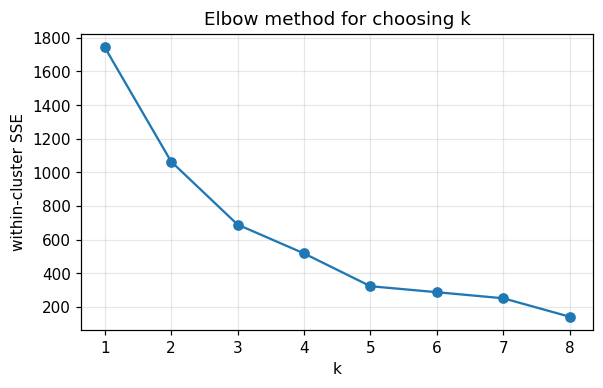

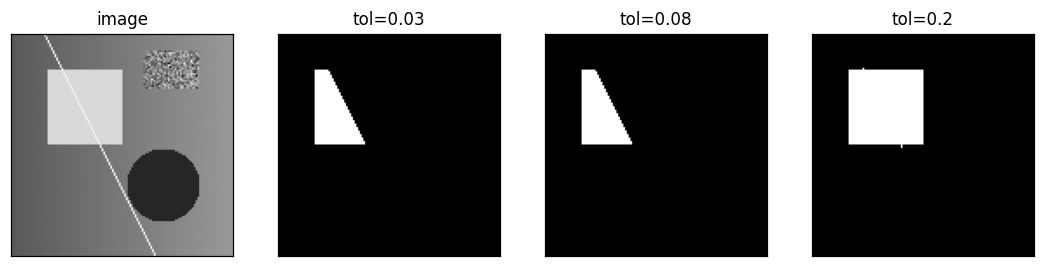

In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. dirsek (elbow) grafiği
ks = range(1, 9)
sse = []
for k in ks:
    labels, centers = kmeans(pixels, k)
    d = ((pixels - centers[labels]) ** 2).sum()
    sse.append(d)
plt.figure(figsize=(6, 3.5))
plt.plot(list(ks), sse, "o-", color="C0")
plt.xlabel("k"); plt.ylabel("küme-içi SSE"); plt.title("k seçimi için dirsek yöntemi")
plt.grid(alpha=0.3); plt.show()

# 3. tolerans taraması
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
show(gray, "görüntü", ax=axes[0])
for ax, tol in zip(axes[1:], [0.03, 0.08, 0.2]):
    r = region_grow(gray, (30, 30), tol)
    show(r.astype(float), f"tol={tol}", ax=ax)
plt.show()

## Recap & what's next

k-means groups pixels by color (and, with position, into superpixels); the Hough transform detects
global lines by voting in parameter space; region growing segments by connectivity. Together they cover
the classical answers to "which pixels belong together?"

**Next — `10_optical_flow_lucas_kanade.ipynb`:** we add *time*. Given two frames, the Lucas–Kanade
method estimates how each pixel moved — using the very same structure tensor that powered the Harris
detector.

---
*Computer Vision · Week 5 · Lecture 9*